In [15]:
from google.colab import files
uploaded = files.upload()

Saving Future Trend Analysis in Education Institutions – Wayanad - Google Review Analysis.csv to Future Trend Analysis in Education Institutions – Wayanad - Google Review Analysis (2).csv


In [16]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Review ID,Institution ID,Institution Name,Course Name,Course Type,Reviewer Name,Review Time,Rating,Review Content,Sentiment,Keyword Theme
0,GR001,INST001,Pazhassiraja College Pulpally,BSc Microbiology,UG,Rahul K,12/03/24,4,Good faculty and supportive teachers,Positive,Faculty
1,GR002,INST001,Pazhassiraja College Pulpally,BBA,UG,Anu Joseph,02/04/24,5,Campus atmosphere is very pleasant,Positive,Campus
2,GR003,INST001,Pazhassiraja College Pulpally,BA English,UG,Arjun P,18/05/24,3,Library is good but labs need improvement,Neutral,Infrastructure
3,GR004,INST002,St Mary's College Sulthan Bathery,BCom Finance,UG,Neha Thomas,28/03/24,4,Good academic support and facilities,Positive,Academics
4,GR005,INST002,St Mary's College Sulthan Bathery,BSc Mathematics,UG,Rahul Das,11/04/24,5,Teachers explain concepts clearly,Positive,Faculty


In [17]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('reviews', conn, index=False, if_exists='replace')

520

# Total reviews

In [18]:
pd.read_sql("""
SELECT COUNT(*) AS total_reviews FROM reviews
""", conn)

,total_reviews
0,520


Average Rating

In [19]:
pd.read_sql("""
SELECT AVG(Rating) AS avg_rating FROM reviews
""", conn)

,avg_rating
0,3.838462


Sentiment Distribution

In [20]:
pd.read_sql("""
SELECT Sentiment, COUNT(*) as count
FROM reviews
GROUP BY Sentiment
""", conn)

,Sentiment,count
0,Neutral,118
1,Positive,402


Top Institutions

In [21]:
pd.read_sql("""
SELECT `Institution Name`, AVG(Rating) as avg_rating
FROM reviews
GROUP BY `Institution Name`
ORDER BY avg_rating DESC
""", conn)

,Institution Name,avg_rating
0,College of Dairy Science and Technology Pookode,4.375000
1,Assumption College of Nursing Sulthan Bathery,4.350000
2,Wayanad Institute of Medical Sciences,4.333333
3,Oriental School of Hotel Management Kalpetta,4.333333
4,Oriental School of Hotel Management,4.333333
5,Oriental College of Hotel Management,4.333333
6,Kerala Veterinary and Animal Sciences Universi...,4.333333
7,Govt Engineering College Mananthavady,4.333333
8,Government Engineering College Mananthavady,4.333333
9,St Mary's College Sulthan Bathery,4.037037


Most Reviewed Institutions

In [22]:
pd.read_sql("""
SELECT `Institution Name`, COUNT(*) as total_reviews
FROM reviews
GROUP BY `Institution Name`
ORDER BY total_reviews DESC
""", conn)

,Institution Name,total_reviews
0,Mary Matha Arts and Science College Mananthavady,39
1,WMO Arts and Science College Muttil,36
2,Government Polytechnic College Kalpetta,36
3,NMSM Government College Kalpetta,33
4,MES College Kalpetta,33
5,Don Bosco Arts and Science College Sulthan Bat...,33
6,NSS College Mananthavady,32
7,Government Engineering College Mananthavady,30
8,St Mary's College Sulthan Bathery,27
9,Government ITI Kalpetta,24


Keyword Theme Analysis

In [23]:
pd.read_sql("""
SELECT `Keyword Theme`, COUNT(*) as frequency
FROM reviews
GROUP BY `Keyword Theme`
ORDER BY frequency DESC
""", conn)

,Keyword Theme,frequency
0,Infrastructure,106
1,Academics,105
2,Faculty,91
3,Labs,47
4,Workshops,46
5,Practical,42
6,Training,33
7,Placement,19
8,Campus,12
9,Projects,11


Time Trend Analysis

In [24]:
pd.read_sql("""
SELECT `Review Time`, AVG(Rating) as avg_rating
FROM reviews
GROUP BY `Review Time`
ORDER BY `Review Time`
""", conn)

,Review Time,avg_rating
0,01/04/24,3.000000
1,02/04/24,5.000000
2,02/05/24,3.750000
3,04/02/24,4.000000
4,04/05/24,4.000000
5,05/02/24,4.047619
6,05/05/24,3.000000
7,06/02/24,4.333333
8,06/05/24,4.000000
9,07/02/24,3.714286


Visualization

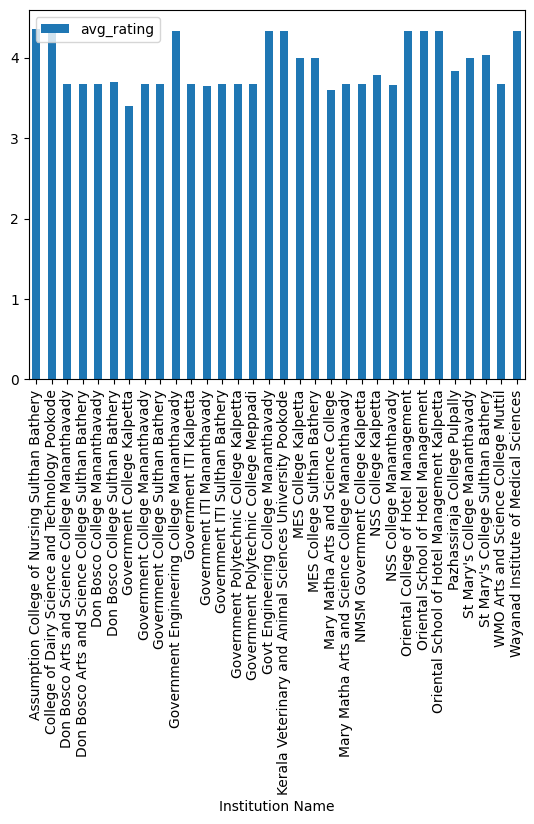

In [25]:
import matplotlib.pyplot as plt

# Avg rating per institution
data = pd.read_sql("""
SELECT `Institution Name`, AVG(Rating) as avg_rating
FROM reviews
GROUP BY `Institution Name`
""", conn)

data.plot(x='Institution Name', y='avg_rating', kind='bar')
plt.xticks(rotation=90)
plt.show()

Negative Reviews

In [26]:
pd.read_sql("""
SELECT *
FROM reviews
WHERE Sentiment = 'Negative' OR Rating <= 2
""", conn)

,Review ID,Institution ID,Institution Name,Course Name,Course Type,Reviewer Name,Review Time,Rating,Review Content,Sentiment,Keyword Theme


In [27]:
result = pd.read_sql("SELECT * FROM reviews", conn)
result.to_csv("processed_output.csv", index=False)

Sentiment Chart

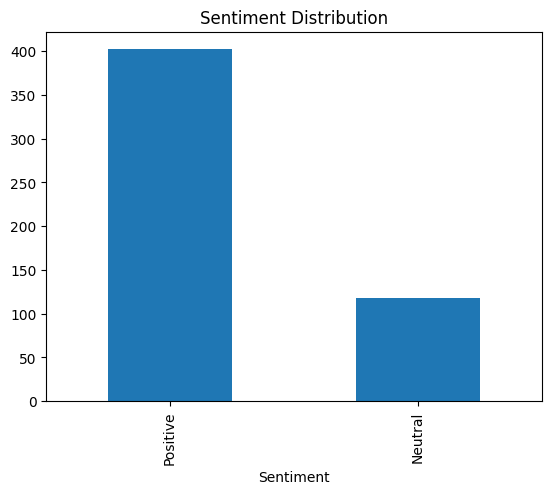

In [30]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

Keyword Theme Chart

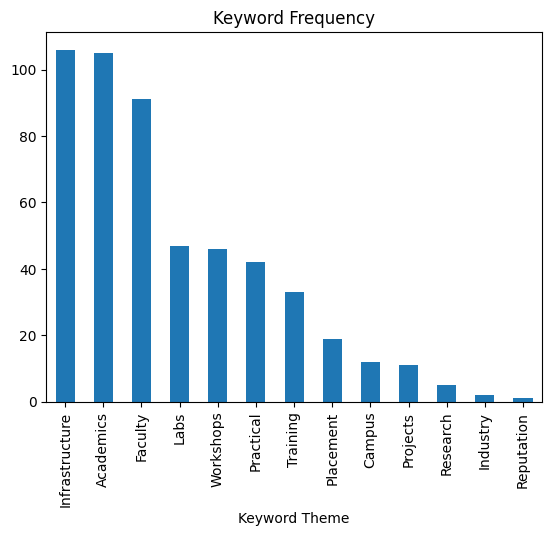

In [31]:
df['Keyword Theme'].value_counts().plot(kind='bar')
plt.xticks(rotation=90)
plt.title("Keyword Frequency")
plt.show()

## Final Insights

- Best institution (highest rating): Govt Engineering College Mananthavady  
- Most common issue (keyword): Infrastructure  
- Most reviews are: Positive  
- Best course type: UG  
- Overall rating trend: Stable  

## Conclusion

This project analyzes student reviews from various educational institutions to understand student satisfaction and identify key strengths and weaknesses.

The analysis shows that most students have a positive perception of their institutions, especially in terms of faculty support and academic quality. However, infrastructure and facilities are the most commonly mentioned areas needing improvement.

Overall, the ratings remain stable, indicating consistent performance across institutions. This analysis can help institutions focus on improving infrastructure while maintaining strong academic standards.